* Dariana Lopera
* Samuel Osorio
* Lenin Ospina
* Ana Maria Alucema


# Proyecto de aula entrega 3: regresion logistica regularizada

El objetivo es construir un modelo predictivo lineal regularizado para estimar la presencia de enfermedad cardiaca a partir de variables clinicas del dataset Cleveland Heart Disease. La variable `target` se transforma en un problema de clasificacion binaria: `0` indica ausencia de enfermedad y `1` indica presencia de enfermedad.

El notebook se organiza segun la rubrica de evaluacion: preparacion de datos, `Pipeline` completo, balanceo para clasificacion, sintonizacion de hiperparametros con validacion cruzada usando una tecnica distinta de `GridSearchCV`, reporte de metricas de validacion, entrenamiento y prueba, y analisis de coeficientes.


## 1. Librerias y carga de datos


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


El archivo de datos se entrega junto con el notebook para que el codigo pueda ejecutarse secuencialmente con **Run All** sin depender de una descarga externa.


In [2]:
data_path = "cleveland_heart_disease.csv"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(data_path, names=columns, na_values="?")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Limpieza y variable objetivo

Se eliminan los registros con valores faltantes y posibles duplicados. Luego se transforma `target` en una variable binaria: `0 = sin enfermedad` y `1 = con enfermedad`. Esta conversion permite usar un modelo lineal regularizado adecuado para clasificacion: regresion logistica.


In [ ]:
df = df.dropna().drop_duplicates().copy()

categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
for col in categorical_features:
    df[col] = df[col].astype(str)

df["target_bin"] = (df["target"] > 0).astype(int)

print(f"Filas: {df.shape[0]}, columnas originales: {len(columns)}")
df[["target", "target_bin"]].head()


Filas: 297, columnas originales: 14


,target,target_bin
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0


In [4]:
class_balance = df["target_bin"].value_counts().sort_index().to_frame("cantidad")
class_balance["proporcion"] = df["target_bin"].value_counts(normalize=True).sort_index()
class_balance.index = ["Sin enfermedad", "Con enfermedad"]
class_balance


,cantidad,proporcion
Sin enfermedad,160,0.538721
Con enfermedad,137,0.461279


Aunque el desbalance no es extremo, la consigna indica que si el problema es de clasificacion debe usarse una tecnica de balanceo. Por eso se usa `class_weight="balanced"` dentro de la regresion logistica. Esta tecnica ajusta el peso de las clases durante el entrenamiento y queda integrada al `Pipeline`, sin alterar artificialmente el conjunto de prueba.


## 3. Separacion de datos y preprocesamiento

Se usa una particion estratificada para conservar la proporcion de clases en entrenamiento y prueba. Las variables categoricas se codifican con `OneHotEncoder`; las variables numericas se escalan o transforman; y la seleccion de caracteristicas se realiza con `SelectKBest`. Todos estos procesos quedan dentro del `Pipeline`, de modo que durante la validacion cruzada cada transformacion se aprende solo con los folds de entrenamiento.


In [5]:
X = df.drop(columns=["target", "target_bin"])
y = df["target_bin"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

numeric_standard = ["age", "trestbps", "chol", "thalach"]
numeric_power = ["oldpeak"]

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("standard", StandardScaler(), numeric_standard),
        ("power", PowerTransformer(), numeric_power),
    ],
    remainder="drop",
)

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("feature_selection", SelectKBest(score_func=f_classif)),
        (
            "model",
            LogisticRegression(
                max_iter=10000,
                random_state=RANDOM_STATE,
                class_weight="balanced",
            ),
        ),
    ]
)

pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('standard', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

## 4. Sintonizacion de hiperparametros

La rubrica solicita validacion cruzada con una tecnica distinta de `GridSearchCV`. Por eso se usa `RandomizedSearchCV`, que prueba combinaciones aleatorias dentro de rangos amplios de hiperparametros. Se optimiza `roc_auc` porque en este problema interesa evaluar la capacidad del modelo para separar pacientes con y sin enfermedad, independientemente de un unico umbral de clasificacion.


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

c_values = np.logspace(-4, 4, 80)

param_distributions = [
    {
        "feature_selection__k": [8, 10, 12, 14, "all"],
        "model__penalty": ["l1"],
        "model__solver": ["saga"],
        "model__C": c_values,
    },
    {
        "feature_selection__k": [8, 10, 12, 14, "all"],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "saga"],
        "model__C": c_values,
    },
    {
        "feature_selection__k": [8, 10, 12, 14, "all"],
        "model__penalty": ["elasticnet"],
        "model__solver": ["saga"],
        "model__C": c_values,
        "model__l1_ratio": np.linspace(0.05, 0.95, 19),
    },
]

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=90,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    error_score="raise",
    return_train_score=True,
)

search.fit(X_train, y_train)

print(f"Mejor AUC-ROC promedio en validacion cruzada: {search.best_score_:.4f}")
print("Mejores hiperparametros:")
for name, value in search.best_params_.items():
    print(f"  {name}: {value}")


Mejor AUC-ROC promedio en validacion cruzada: 0.9079
Mejores hiperparametros:
  model__solver: saga
  model__penalty: elasticnet
  model__l1_ratio: 0.95
  model__C: 2.855592301990106
  feature_selection__k: all


In [7]:
cv_results = pd.DataFrame(search.cv_results_)
cols = [
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_model__penalty",
    "param_model__C",
    "param_feature_selection__k",
    "param_model__l1_ratio",
]

best_results = (
    cv_results[cols]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

best_results


,mean_test_score,std_test_score,mean_train_score,param_model__penalty,param_model__C,param_feature_selection__k,param_model__l1_ratio
0,0.907926,0.021138,0.938648,elasticnet,2.855592,all,0.95
1,0.907489,0.019699,0.938944,elasticnet,2.855592,all,0.55
2,0.905950,0.027440,0.934683,l1,1.123655,all,NaN
3,0.902975,0.034700,0.928707,elasticnet,0.889953,14,0.10
4,0.901914,0.015741,0.940791,l2,23.285663,all,NaN
5,0.900458,0.017894,0.940995,elasticnet,37.121050,all,0.30
6,0.900125,0.035624,0.931088,elasticnet,1.791284,14,0.10
7,0.900125,0.035624,0.931205,elasticnet,1.791284,14,0.15
8,0.899688,0.035248,0.932147,elasticnet,2.855592,14,0.30
9,0.899542,0.016851,0.940966,elasticnet,74.716707,all,0.35


## 5. Evaluacion del modelo

Se reportan metricas de validacion cruzada, entrenamiento y prueba. Para el ajuste de hiperparametros se uso AUC-ROC, y para interpretar el desempeno final se incluyen exactitud, precision, recall, F1 y AUC-ROC. El recall de la clase con enfermedad es especialmente importante porque un falso negativo podria dejar sin alerta a un paciente que requiere revision medica.


In [8]:
best_model = search.best_estimator_

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_metrics = cross_validate(best_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_summary = pd.DataFrame(
    {
        "metrica": list(scoring.keys()),
        "validacion_cruzada_media": [cv_metrics[f"test_{metric}"].mean() for metric in scoring],
        "validacion_cruzada_desv": [cv_metrics[f"test_{metric}"].std() for metric in scoring],
    }
)

cv_summary


,metrica,validacion_cruzada_media,validacion_cruzada_desv
0,accuracy,0.830430,0.056646
1,precision,0.826825,0.084891
2,recall,0.810526,0.063158
3,f1,0.815628,0.055546
4,roc_auc,0.907926,0.021138


In [9]:
def evaluate_split(model, X_data, y_data, split_name):
    y_pred = model.predict(X_data)
    y_proba = model.predict_proba(X_data)[:, 1]
    return {
        "conjunto": split_name,
        "accuracy": accuracy_score(y_data, y_pred),
        "precision": precision_score(y_data, y_pred),
        "recall": recall_score(y_data, y_pred),
        "f1": f1_score(y_data, y_pred),
        "roc_auc": roc_auc_score(y_data, y_proba),
    }


metrics_df = pd.DataFrame(
    [
        evaluate_split(best_model, X_train, y_train, "Entrenamiento"),
        evaluate_split(best_model, X_test, y_test, "Prueba"),
    ]
)

metrics_df


,conjunto,accuracy,precision,recall,f1,roc_auc
0,Entrenamiento,0.850242,0.840426,0.831579,0.835979,0.935056
1,Prueba,0.866667,0.875000,0.833333,0.853659,0.921131


In [10]:
y_test_pred = best_model.predict(X_test)

print(classification_report(y_test, y_test_pred, target_names=["Sin enfermedad", "Con enfermedad"]))


                precision    recall  f1-score   support

Sin enfermedad       0.86      0.90      0.88        48
Con enfermedad       0.88      0.83      0.85        42

      accuracy                           0.87        90
     macro avg       0.87      0.86      0.87        90
  weighted avg       0.87      0.87      0.87        90



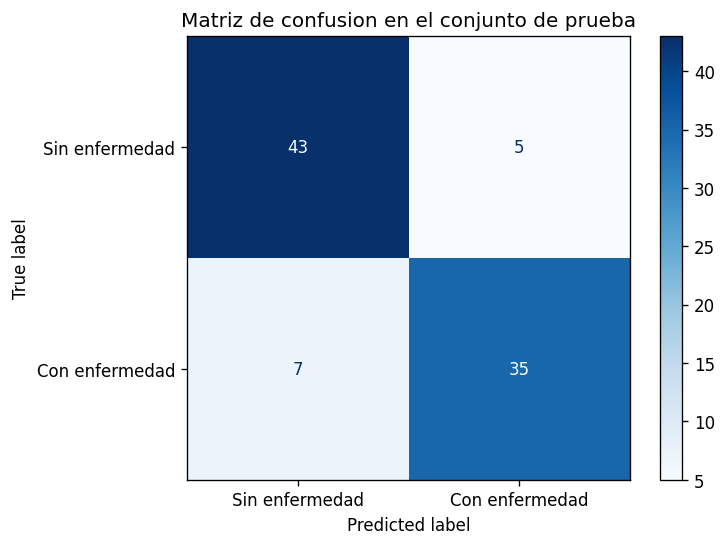

In [11]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    display_labels=["Sin enfermedad", "Con enfermedad"],
    cmap="Blues",
)
plt.title("Matriz de confusion en el conjunto de prueba")
plt.show()


La comparacion entre entrenamiento y prueba permite revisar si hay sobreajuste. Si las metricas de prueba se mantienen cercanas a las de entrenamiento y validacion cruzada, el modelo generaliza de forma razonable. En este contexto, un buen recall para la clase positiva indica que el modelo identifica una proporcion alta de pacientes con enfermedad cardiaca.


## 6. Coeficientes e interpretacion

Los coeficientes se extraen despues del preprocesamiento y de la seleccion de caracteristicas. Un coeficiente positivo aumenta la probabilidad estimada de enfermedad cardiaca; uno negativo la reduce. La magnitud absoluta indica mayor influencia dentro de las variables usadas por el modelo.


In [12]:
feature_names = best_model.named_steps["preprocessing"].get_feature_names_out()
selector = best_model.named_steps["feature_selection"]
selected_features = feature_names[selector.get_support()]

coef_df = pd.DataFrame(
    {
        "feature": selected_features,
        "coeficiente": best_model.named_steps["model"].coef_[0],
    }
)
coef_df["importancia_abs"] = coef_df["coeficiente"].abs()
coef_df["direccion"] = np.where(
    coef_df["coeficiente"] > 0,
    "aumenta la probabilidad estimada",
    "disminuye la probabilidad estimada",
)
coef_df = coef_df.sort_values("importancia_abs", ascending=False).reset_index(drop=True)

coef_df


,feature,coeficiente,importancia_abs,direccion
0,onehot__ca_2.0,2.544314,2.544314,aumenta la probabilidad estimada
1,onehot__ca_1.0,1.925996,1.925996,aumenta la probabilidad estimada
2,onehot__cp_4.0,1.748525,1.748525,aumenta la probabilidad estimada
3,onehot__thal_7.0,1.707019,1.707019,aumenta la probabilidad estimada
4,onehot__sex_1.0,1.420620,1.420620,aumenta la probabilidad estimada
5,onehot__slope_3.0,1.240801,1.240801,aumenta la probabilidad estimada
6,onehot__slope_2.0,1.142670,1.142670,aumenta la probabilidad estimada
7,onehot__ca_3.0,0.671850,0.671850,aumenta la probabilidad estimada
8,onehot__exang_1.0,0.650443,0.650443,aumenta la probabilidad estimada
9,onehot__cp_3.0,-0.649952,0.649952,disminuye la probabilidad estimada


,feature,coeficiente,direccion
0,onehot__ca_2.0,2.544314,aumenta la probabilidad estimada
1,onehot__ca_1.0,1.925996,aumenta la probabilidad estimada
2,onehot__cp_4.0,1.748525,aumenta la probabilidad estimada
3,onehot__thal_7.0,1.707019,aumenta la probabilidad estimada
4,onehot__sex_1.0,1.420620,aumenta la probabilidad estimada
5,onehot__slope_3.0,1.240801,aumenta la probabilidad estimada
6,onehot__slope_2.0,1.142670,aumenta la probabilidad estimada
7,onehot__ca_3.0,0.671850,aumenta la probabilidad estimada
8,onehot__exang_1.0,0.650443,aumenta la probabilidad estimada
9,onehot__cp_3.0,-0.649952,disminuye la probabilidad estimada


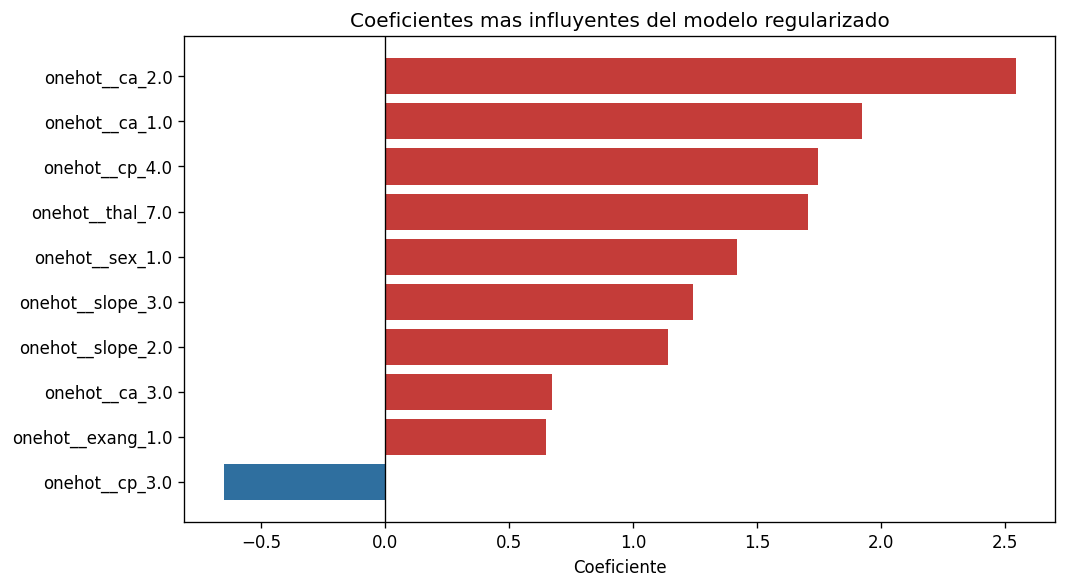

In [13]:
top_coef = coef_df.head(10).copy()

plt.figure(figsize=(9, 5))
colors = np.where(top_coef["coeficiente"] > 0, "#c43c39", "#2f6f9f")
plt.barh(top_coef["feature"], top_coef["coeficiente"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.gca().invert_yaxis()
plt.title("Coeficientes mas influyentes del modelo regularizado")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

top_coef[["feature", "coeficiente", "direccion"]]


Las caracteristicas con coeficientes positivos aumentan la probabilidad estimada de enfermedad cardiaca dentro del modelo, mientras que las negativas la disminuyen. Como las variables numericas fueron escaladas y las categoricas codificadas, los coeficientes pueden compararse mejor que en los datos crudos. Esta interpretacion es predictiva y no debe asumirse como una relacion causal medica.


## Conclusion

El notebook cumple los requisitos centrales de la entrega: separa entrenamiento y prueba, aplica transformaciones independientes para variables numericas y categoricas, integra preprocesamiento, seleccion de caracteristicas, balanceo de clases y regresion logistica regularizada en un `Pipeline`, sintoniza hiperparametros con `RandomizedSearchCV` y validacion cruzada, reporta metricas de validacion, entrenamiento y prueba, y presenta los coeficientes emparejados con sus caracteristicas transformadas para interpretar la importancia del modelo.
